In [4]:
#instalacja bibliotek
import pandas as pd

In [14]:
#wczytanie danych 
dane = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
#wyświetlanie wgranych danych
print("Pierwsze 5 rzędów")
dane.head(5)

Pierwsze 5 rzędów


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
#informacje na temat danych 
dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
#zmiana typu kolumny TotalCharges z object to float 
dane["TotalCharges"] = pd.to_numeric(dane['TotalCharges'], errors='coerce')

In [20]:
#sprawdzenie ilości pól z brakiem danych
print(dane.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [22]:
#Wyrzucamy wiersze, które zawierają puste pola z racji większej ilości rekordów
dane.dropna(axis = 0, inplace= True)

In [24]:
#Sprawdzamy status pustychj pól po usunięciu
dane.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
#Liczymy balans klas
dane["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [48]:
#grupujemy według odejść klientów oraz obliczamy miesięczne opłaty dla poszczególnych grup
dane_pogrupowane_miesieczne = dane.groupby("Churn")["MonthlyCharges"]
dane_pogrupowane_miesieczne.mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [50]:
#grupujemy według odejść klientów oraz jaki typ umowy posiadali
dane_pogrupowane_umowa = dane.groupby("Churn")["Contract"]
dane_pogrupowane_umowa.value_counts()

Churn  Contract      
No     Month-to-month    2220
       Two year          1637
       One year          1306
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

In [52]:
#grupujemy według odejść klientów oraz jaki rodzaj internetu posiadali
dane_pogrupowane_internet = dane.groupby("Churn")["InternetService"]
dane_pogrupowane_internet.value_counts()

Churn  InternetService
No     DSL                1957
       Fiber optic        1799
       No                 1407
Yes    Fiber optic        1297
       DSL                 459
       No                  113
Name: count, dtype: int64

In [54]:
#grupujemy według odejść klientów oraz czy posiadali wsparcie techniczne
dane_pogrupowane_support = dane.groupby("Churn")["TechSupport"]
dane_pogrupowane_support.value_counts()

Churn  TechSupport        
No     No                     2026
       Yes                    1730
       No internet service    1407
Yes    No                     1446
       Yes                     310
       No internet service     113
Name: count, dtype: int64

In [56]:
#grupujemy według odejść klientów oraz rodzaj metody płatności
dane_pogrupowane_payment = dane.groupby("Churn")["PaymentMethod"]
dane_pogrupowane_payment.value_counts()

Churn  PaymentMethod            
No     Mailed check                 1296
       Electronic check             1294
       Credit card (automatic)      1289
       Bank transfer (automatic)    1284
Yes    Electronic check             1071
       Mailed check                  308
       Bank transfer (automatic)     258
       Credit card (automatic)       232
Name: count, dtype: int64

In [58]:
#grupujemy według odejść klientów oraz czy są seniorami
dane_pogrupowane_senior = dane.groupby("Churn")["SeniorCitizen"]
dane_pogrupowane_senior.value_counts()

Churn  SeniorCitizen
No     0                4497
       1                 666
Yes    0                1393
       1                 476
Name: count, dtype: int64

In [67]:
#Importujemy bilbioteke seaborn 
import seaborn as sns
import matplotlib.pyplot as plt 

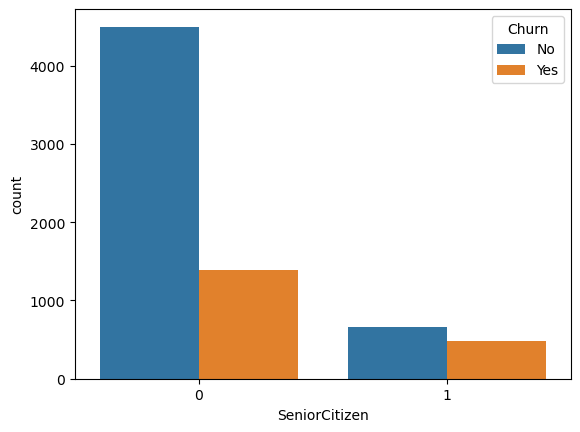

In [69]:
#Tworzymy wykres countplot
sns.countplot(data=dane, x='SeniorCitizen', hue='Churn')
plt.show()

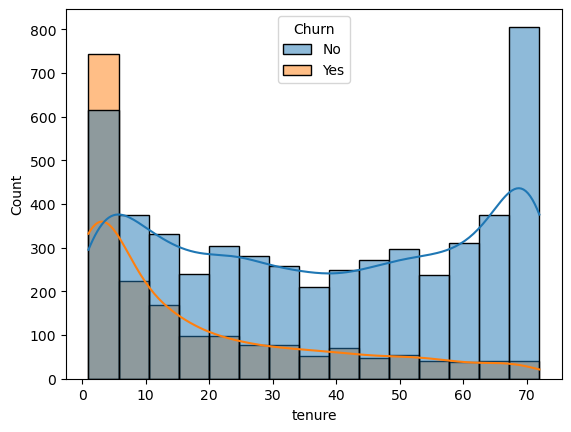

In [85]:
#tworzymy histogram
sns.histplot(data=dane, x='tenure', kde=True, hue='Churn')
plt.show()

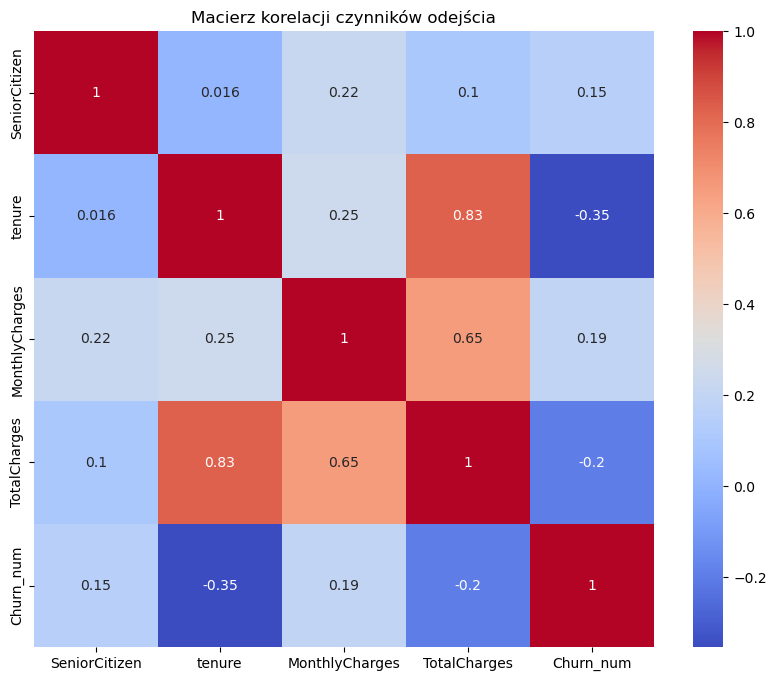

In [98]:
#Stworzenie nowej kolumny 0/1 dla kolumny churn
dane["Churn_num"] = dane["Churn"].map({'Yes': 1, 'No': 0})
#Wybranie tylko numerycznych kolumn
dane_numeryczne = dane.select_dtypes(include=['number'])
#Obliczenie korelacji
macierz_korelacji = dane_numeryczne.corr()
#Stworzenie wykresu
plt.figure(figsize=(10, 8))
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm')
plt.title("Macierz korelacji czynników odejścia")
plt.show()

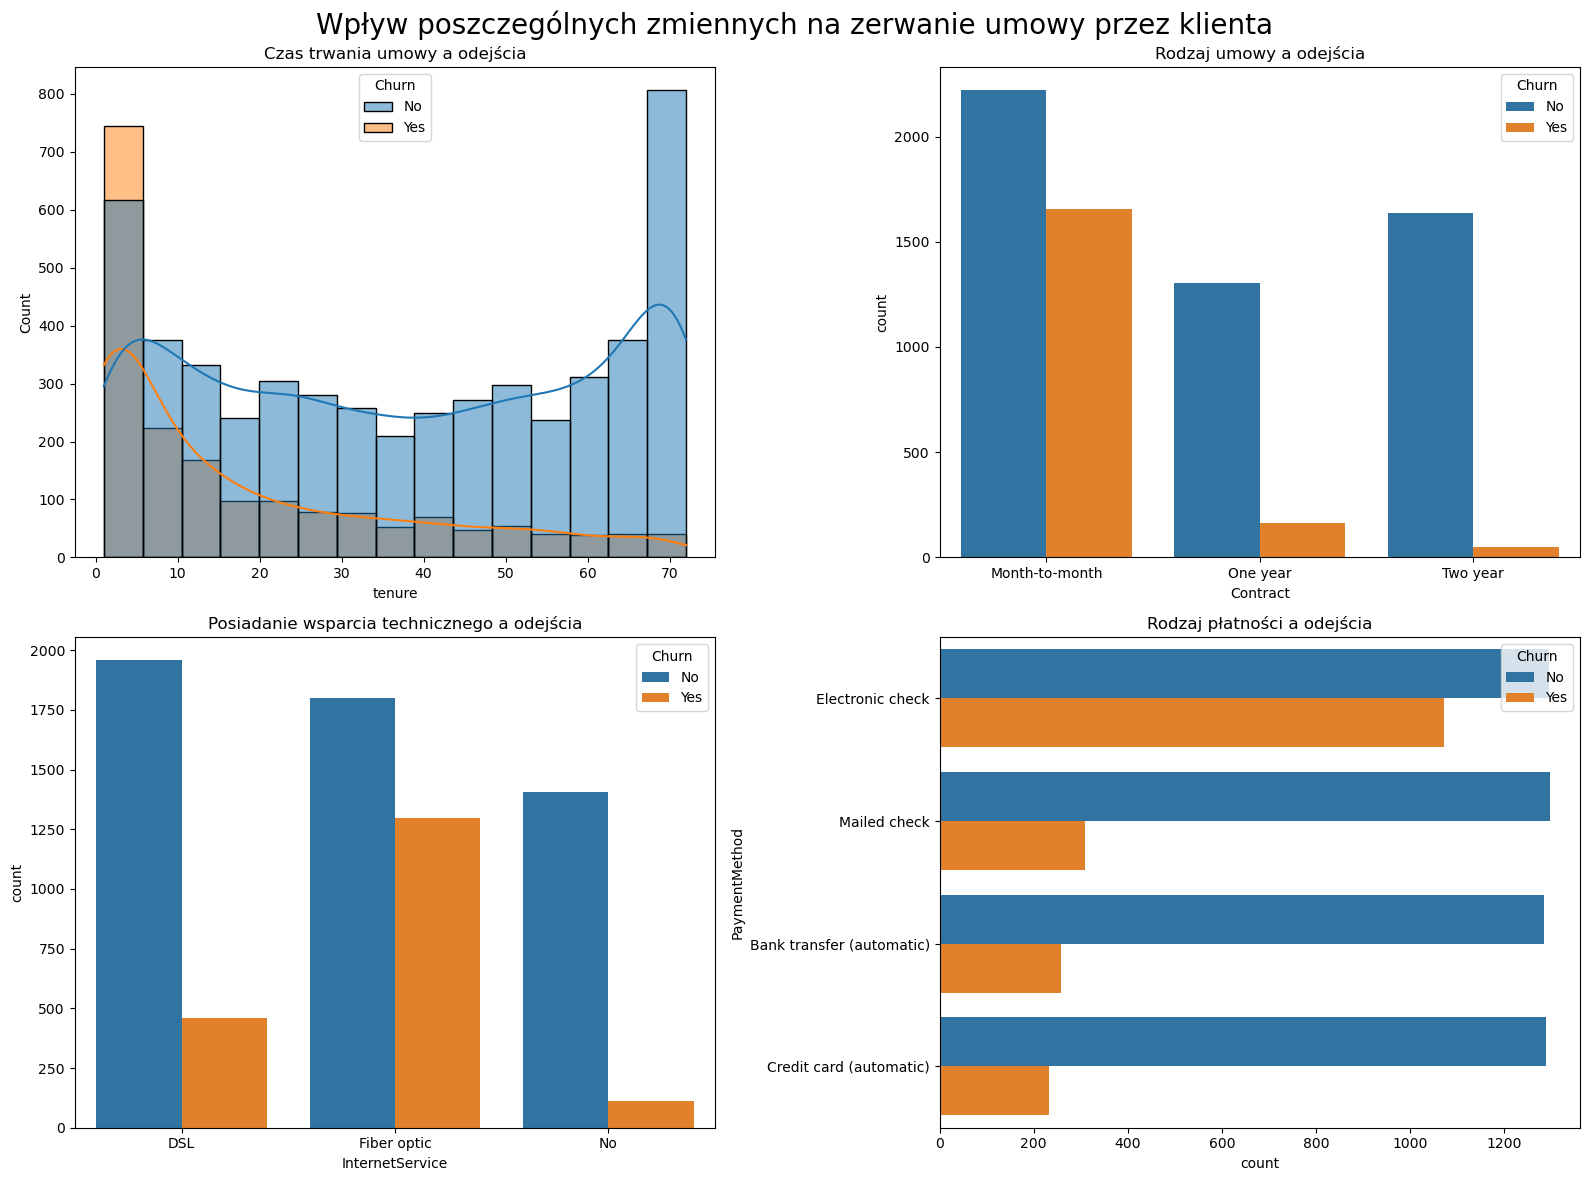

In [91]:
#tworzymy tabele wykresów
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.histplot(data = dane, x='tenure', hue='Churn', kde=True, ax=axes[0,0]).set_title("Czas trwania umowy a odejścia")
sns.countplot(data = dane, x="Contract", hue="Churn", ax=axes[0,1]).set_title("Rodzaj umowy a odejścia")
sns.countplot(data = dane, x="InternetService", hue="Churn", ax=axes[1,0]).set_title("Posiadanie wsparcia technicznego a odejścia")
sns.countplot(data = dane, y="PaymentMethod", hue="Churn", ax=axes[1,1]).set_title("Rodzaj płatności a odejścia")
fig.suptitle('Wpływ poszczególnych zmiennych na zerwanie umowy przez klienta', fontsize=20)
plt.tight_layout()
plt.show()

## Kluczowe Wnioski z Analizy Odejść :
* **Ryzyko Nowego Klienta:** Największy odpływ następuje w ciągu pierwszych **6 miesięcy**. Wymagana lepsza opieka w fazie wdrożenia.
* **Problem Usługi:** Klienci ze **światłowodem** odchodzą dwa razy częściej niż z DSL. Sugeruje to problemy techniczne lub zbyt wysoką cenę względem konkurencji.
* **Bariery Płatności:** Metoda **Electronic Check** ma najwyższy wskaźnik rezygnacji. Przejście na płatności automatyczne drastycznie zwiększa lojalność.
* **Siła Kontraktu:** Umowy miesięczne to główne źródło strat. Promowanie umów rocznych jest kluczowe dla stabilności bazy klientów.